In [122]:
pip install pennylane matplotlib

In [123]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

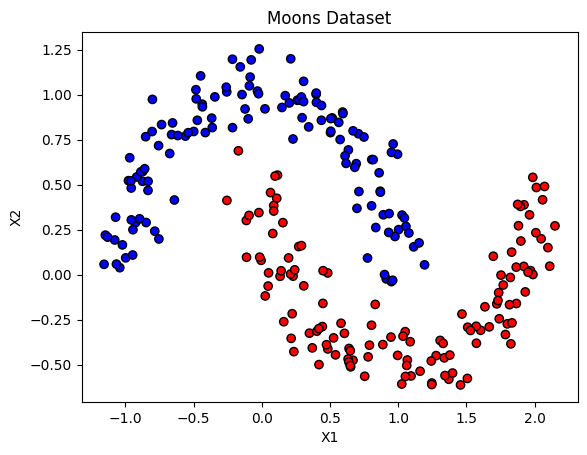

In [124]:
# Generate the data
X, Y = make_moons(n_samples=256, noise=0.1, random_state=42)

# Plot it
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='bwr', edgecolor='k')
plt.title("Moons Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()
Y = Y * 2 - 1  # shift label from {0, 1} to {-1, 1}

In [125]:
# Split original data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# Scale to [0, 1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def float_to_binary(vec, total_bits=8):
    # Calculate bits per feature based on vector length
    bits_per_feature = total_bits // len(vec)

    # Ensure at least 1 bit per feature
    if bits_per_feature < 1:
        raise ValueError(f"Can't represent {len(vec)} features in {total_bits} bits")

    bin_vec = []
    for val in vec:
        # Scale value between 0 and 2^bits_per_feature - 1
        scaled = int(val * (2**bits_per_feature - 1))
        # Format as binary with proper padding
        bin_str = format(scaled, f'0{bits_per_feature}b')
        # Add each bit to the result vector
        bin_vec.extend([int(b) for b in bin_str])

    # Verify we have exactly the requested number of bits
    if len(bin_vec) != total_bits:
        raise ValueError(f"Generated {len(bin_vec)} bits instead of {total_bits}")

    return np.array(bin_vec)

# Apply encoding
X_train_binary = np.array([float_to_binary(x) for x in X_train_scaled])
X_test_binary = np.array([float_to_binary(x) for x in X_test_scaled])
X_test_binary

tensor([[0, 0, 0, 0, 0, 1, 0, 1],
        [1, 0, 0, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 1, 1, 1],
        [1, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 1, 1, 0, 1],
        [0, 1, 0, 1, 1, 0, 0, 0],
        [1, 1, 1, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 1, 1, 1, 0, 1, 1],
        [0, 0, 0, 1, 0, 1, 1, 0],
        [0, 0, 0, 1, 1, 0, 0, 1],
        [0, 0, 0, 0, 1, 0, 0, 0],
        [1, 0, 0, 1, 1, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 1],
        [0, 1, 0, 1, 1, 1, 0, 0],
        [1, 0, 1, 1, 0, 0, 0, 1],
        [1, 0, 0, 1, 0, 1, 1, 1],
        [0, 1, 1, 1, 0, 0, 1, 1],
        [0, 1, 0, 1, 0, 1, 1, 1],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 0, 0, 0, 0, 1],
        [0, 1, 1, 1, 1, 0, 1, 1],
        [1, 1, 0, 0, 0, 0, 1, 0],
        [1, 0, 0, 1, 0, 1, 0, 0],
        [0, 1, 0, 0, 1, 1, 0, 1],
        [0, 1, 1, 0, 0, 0, 1, 1],
        [0, 1, 1, 0, 0, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 0],
        [0, 0,

In [126]:
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

def layer(layer_weights):
    for wire in range(8):
        qml.Rot(*layer_weights[wire], wires=wire)

    for wires in ([0, 1], [1, 2], [2, 3],[3, 4], [4, 5], [5, 6], [6, 7], [7, 0]):
        qml.CNOT(wires)

def state_preparation(z):
    qml.BasisState(z, wires=[0, 1, 2, 3, 4, 5, 6, 7])

@qml.qnode(dev)
def circuit(weights, z):
    state_preparation(z)

    for layer_weights in weights:
        layer(layer_weights)

    return qml.expval(qml.PauliZ(0))

def variational_classifier(weights, bias, z):
    return circuit(weights, z) + bias

def square_loss(labels, predictions):
    return np.mean((labels - qml.math.stack(predictions)) ** 2)

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def cost(weights, bias, X, Y):
    predictions = [variational_classifier(weights, bias, x) for x in X]
    return square_loss(Y, predictions)

In [127]:
np.random.seed(0)
num_qubits = 8
num_layers = 4
weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)

print("Weights:", weights_init)
print("Bias: ", bias_init)

Weights: [[[ 0.01764052  0.00400157  0.00978738]
  [ 0.02240893  0.01867558 -0.00977278]
  [ 0.00950088 -0.00151357 -0.00103219]
  [ 0.00410599  0.00144044  0.01454274]
  [ 0.00761038  0.00121675  0.00443863]
  [ 0.00333674  0.01494079 -0.00205158]
  [ 0.00313068 -0.00854096 -0.0255299 ]
  [ 0.00653619  0.00864436 -0.00742165]]

 [[ 0.02269755 -0.01454366  0.00045759]
  [-0.00187184  0.01532779  0.01469359]
  [ 0.00154947  0.00378163 -0.00887786]
  [-0.01980796 -0.00347912  0.00156349]
  [ 0.01230291  0.0120238  -0.00387327]
  [-0.00302303 -0.01048553 -0.01420018]
  [-0.0170627   0.01950775 -0.00509652]
  [-0.00438074 -0.01252795  0.0077749 ]]

 [[-0.01613898 -0.0021274  -0.00895467]
  [ 0.00386902 -0.00510805 -0.01180632]
  [-0.00028182  0.00428332  0.00066517]
  [ 0.00302472 -0.00634322 -0.00362741]
  [-0.0067246  -0.00359553 -0.00813146]
  [-0.01726283  0.00177426 -0.00401781]
  [-0.01630198  0.00462782 -0.00907298]
  [ 0.00051945  0.00729091  0.00128983]]

 [[ 0.01139401 -0.0123482

In [128]:
opt = NesterovMomentumOptimizer(0.2)
batch_size = 12
weights = weights_init
bias = bias_init
for it in range(100):
    # Update the weights by one optimizer step, using only a limited batch of data
    batch_index = np.random.randint(0, len(X_train_binary), (batch_size,))
    X_batch = X_train_binary[batch_index]
    Y_batch = y_train[batch_index]
    weights, bias = opt.step(cost, weights, bias, X=X_batch, Y=Y_batch)

    # Compute accuracy
    predictions = [np.sign(variational_classifier(weights, bias, x)) for x in X_train_binary]

    current_cost = cost(weights, bias, X_train_binary, y_train)
    acc = accuracy(y_train, predictions)

    print(f"Iter: {it+1:4d} | Cost: {current_cost:0.7f} | Accuracy: {acc:0.7f}")

Iter:    1 | Cost: 2.4276030 | Accuracy: 0.3921569
Iter:    2 | Cost: 2.4187673 | Accuracy: 0.3921569
Iter:    3 | Cost: 2.3693041 | Accuracy: 0.3921569
Iter:    4 | Cost: 2.2024696 | Accuracy: 0.3921569
Iter:    5 | Cost: 1.8498982 | Accuracy: 0.3921569
Iter:    6 | Cost: 1.3813167 | Accuracy: 0.3921569
Iter:    7 | Cost: 1.1061380 | Accuracy: 0.3921569
Iter:    8 | Cost: 1.0375082 | Accuracy: 0.4901961
Iter:    9 | Cost: 1.0591293 | Accuracy: 0.5000000
Iter:   10 | Cost: 1.0202153 | Accuracy: 0.5000000
Iter:   11 | Cost: 1.0113243 | Accuracy: 0.5000000
Iter:   12 | Cost: 1.0267835 | Accuracy: 0.5000000
Iter:   13 | Cost: 0.9983213 | Accuracy: 0.5000000
Iter:   14 | Cost: 0.9862890 | Accuracy: 0.5049020
Iter:   15 | Cost: 1.0242386 | Accuracy: 0.5000000
Iter:   16 | Cost: 1.0434385 | Accuracy: 0.5000000
Iter:   17 | Cost: 1.0064033 | Accuracy: 0.5000000
Iter:   18 | Cost: 0.9799911 | Accuracy: 0.5000000
Iter:   19 | Cost: 0.8799359 | Accuracy: 0.6715686
Iter:   20 | Cost: 0.8780957 | 

In [129]:
predictions_test = [np.sign(variational_classifier(weights, bias, x)) for x in X_test_binary]

for x,y,p in zip(X_test_binary, y_test, predictions_test):
    print(f"x = {x}, y = {y}, pred={p}")

acc_test = accuracy(y_test, predictions_test)
print("Accuracy on unseen data:", acc_test)

x = [0 0 0 0 0 1 0 1], y = -1, pred=-1.0
x = [1 0 0 0 0 0 0 1], y = 1, pred=1.0
x = [1 0 0 0 0 1 1 1], y = -1, pred=-1.0
x = [1 0 1 1 0 0 0 0], y = 1, pred=1.0
x = [0 1 0 0 1 1 0 1], y = -1, pred=-1.0
x = [0 1 0 1 1 0 0 0], y = 1, pred=1.0
x = [1 1 1 0 1 0 0 0], y = 1, pred=1.0
x = [0 0 0 0 0 1 1 1], y = -1, pred=-1.0
x = [0 0 1 1 1 0 1 1], y = -1, pred=-1.0
x = [0 0 0 1 0 1 1 0], y = -1, pred=-1.0
x = [0 0 0 1 1 0 0 1], y = -1, pred=-1.0
x = [0 0 0 0 1 0 0 0], y = -1, pred=-1.0
x = [1 0 0 1 1 0 0 0], y = -1, pred=1.0
x = [1 0 0 0 0 0 0 1], y = 1, pred=1.0
x = [0 1 0 1 1 1 0 0], y = -1, pred=-1.0
x = [1 0 1 1 0 0 0 1], y = 1, pred=1.0
x = [1 0 0 1 0 1 1 1], y = -1, pred=-1.0
x = [0 1 1 1 0 0 1 1], y = 1, pred=1.0
x = [0 1 0 1 0 1 1 1], y = 1, pred=1.0
x = [1 1 0 0 0 0 0 0], y = 1, pred=1.0
x = [0 1 1 0 0 0 0 1], y = 1, pred=-1.0
x = [0 1 1 1 1 0 1 1], y = -1, pred=1.0
x = [1 1 0 0 0 0 1 0], y = 1, pred=1.0
x = [1 0 0 1 0 1 0 0], y = -1, pred=-1.0
x = [0 1 0 0 1 1 0 1], y = -1, pred=-1.